In [73]:
from sklearn import linear_model as sk_linear_model#linear model
from sklearn.model_selection import train_test_split #training splits
import matplotlib.pyplot as plt # plotting library
import numpy as np
import pandas

#to run a command as if i was running it in a terminal, prefix the command with an exlamation mark eg !ls -la datasets

1. Load Data

In [32]:
data = pandas.read_csv("../datasets/Advertising.csv")
data

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


2. EXtract required columns

In [33]:
X = data['TV'].values
Y = data['Sales'].values

3. Create a function for graphing a line together with data points

In [38]:
def plot_scatter_line(X, Y, m = None, c = None):
    if m is not None and c is not None :
        x_line = np.linspace(min(X), max(X), 100)
        y_line = m * x_line + c
        plt.plot(x_line, y_line, color='red', label='fitted line')
    plt.scatter(X, Y, color='blue', label='data points')
    plt.xlabel('Ads spendature')
    plt.ylabel('Sales')

    plt.legend()

    plt.show()


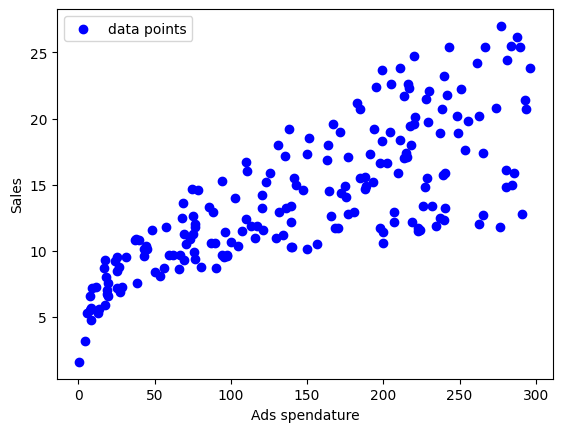

In [29]:
plot_scatter_line(X=X, Y=Y)

4. Create train test split

In [43]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

5. Train the linear regression model with the training data

In [45]:
def linear_model(m, C, X):
    return m * X + C

5.1. find average x and average y from training data set

In [46]:
Y_train_bar = Y_train.mean()
X_train_bar = X_train.mean()

5.2. find TSS( total sum of sqaures)

In [54]:
TSS = np.sum((Y_train - Y_train_bar) ** 2)
TSS

np.float64(4263.7519375)

5.3. caulate RSS(residual sum of squares)

In [58]:
m = 3
c = 0
Rand_rss = np.sum((Y_train - linear_model(m,c,X_train))** 2)
Rand_rss

np.float64(37640376.25)

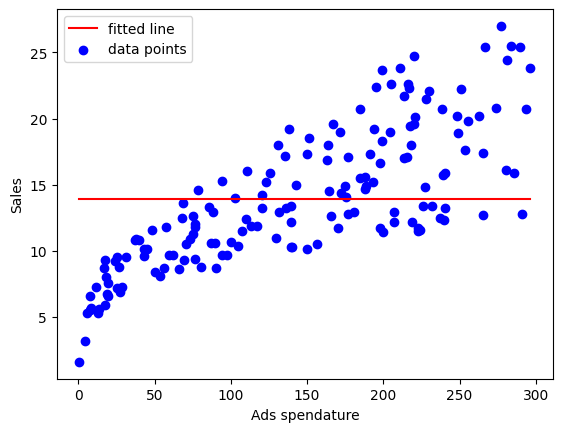

In [53]:
plot_scatter_line(X=X_train, Y=Y_train, m=0, c=Y_train_bar)

5.4. model training

we are to find B0 and B1. Using the least squares method

In [61]:
B1 = np.sum((X_train - X_train_bar) * (Y_train - Y_train_bar))/np.sum((X_train - X_train_bar)**2)
B1

np.float64(0.04847438044805829)

In [62]:
B0 = Y_train_bar - X_train_bar * B1
B0

np.float64(6.982147980135403)

5.5. Find RSS when using best possible B0 and B1

In [65]:
RSS = np.sum((Y_train - linear_model(B1,B0,X_train))** 2)
RSS

np.float64(1580.7997934290972)

5.6. Plot best possible model

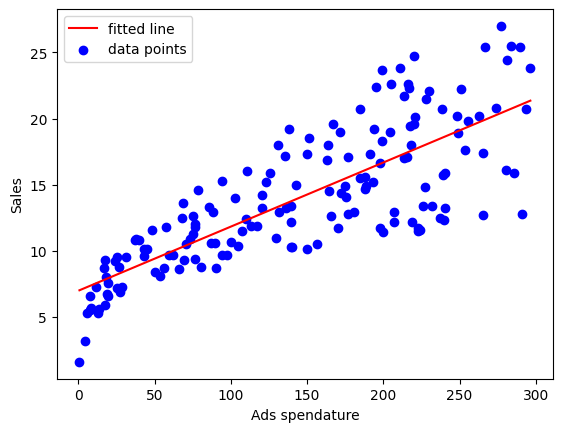

In [64]:
plot_scatter_line(X=X_train, Y=Y_train, m=B1, c=B0)

In [67]:
R2 = 1 - (RSS/TSS)
R2

np.float64(0.629246772185349)

In [70]:
RSE =  np.sqrt(RSS/(X_train.size - 2))
RSE

np.float64(3.1630779288105537)

In [74]:
model_0 = sk_linear_model.LinearRegression()

In [75]:
model_0.fit(X_train.reshape(-1, 1), Y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [78]:
M = model_0.coef_
Y_intercept = model_0.intercept_
M,Y_intercept

(array([0.04847438]), np.float64(6.982147980135403))

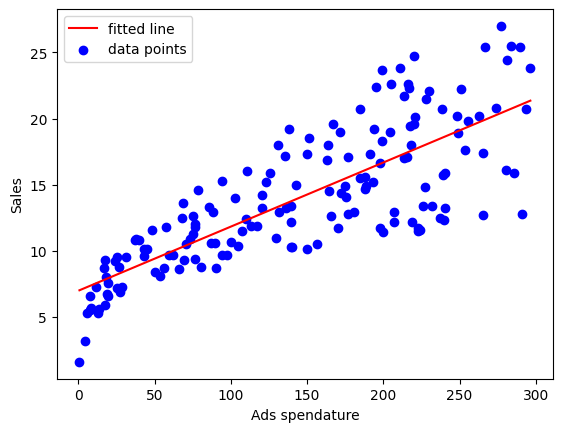

In [79]:
plot_scatter_line(X=X_train, Y=Y_train, m=M, c=Y_intercept)